# Phase 2 + 3 — Emotion Analysis & Emotion-Aware Summarization

**What this notebook does:**

1. Loads the segmented JSONs you produced in Week 1
2. Runs every sentence through a pre-trained emotion classifier (Phase 2)
3. Plots the story's emotional arc
4. Builds an emotion-aware summary that keeps the high-emotion moments verbatim (Phase 3)
5. Saves everything to `data/processed/` ready for Phase 4 (TTS)

**Models we'll download (one-time, cached afterwards):**
- `j-hartmann/emotion-english-distilroberta-base` — ~330MB
- `sshleifer/distilbart-cnn-12-6` — ~300MB

**Expected runtime on M4 / 16GB:**
- First run: 5–10 min (model downloads + inference)
- Subsequent runs: 1–3 min (models cached, just inference)

**Memory discipline:** we explicitly unload the emotion model before loading the summarizer so we never hold both in RAM at once.

## Step 1 — Imports & setup

In [1]:
import sys
import json
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import (
    story_downloader,
    text_loader,
    segmenter,
    emotion_analyzer,
    emotion_visualizer,
    summarizer,
)

print(f"Project root: {project_root}")
print(f"Selected device: {emotion_analyzer._pick_device()}")
print("Modules imported.")

Project root: /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook
Selected device: mps
Modules imported.


## Step 2 — Make sure Week 1 outputs exist

We re-run Week 1's pipeline if needed so this notebook is self-contained.

In [2]:
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

downloaded = story_downloader.download_all(raw_dir)

for key in downloaded:
    seg_path = processed_dir / f"{key}_segmented.json"
    if not seg_path.exists():
        # load_story_by_key applies the section markers in TEST_STORIES
        # so anthology files get narrowed to the single story.
        text = story_downloader.load_story_by_key(key, raw_dir)
        segs = segmenter.segment_story(text)
        with seg_path.open("w", encoding="utf-8") as f:
            json.dump(segs, f, ensure_ascii=False, indent=2)
        print(f"  Segmented: {key} ({segs['stats']['num_sentences']} sentences)")
    else:
        print(f"  Already segmented: {key}")

Stories: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3758.34it/s]

[cached] The Gift of the Magi -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/raw/gift_of_the_magi.txt
[cached] The Necklace -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/raw/the_necklace.txt
[cached] The Tell-Tale Heart -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/raw/tell_tale_heart.txt
  Already segmented: gift_of_the_magi
  Already segmented: the_necklace
  Already segmented: tell_tale_heart


## Step 3 — Run emotion analysis on one story

First time only: downloads ~330MB. Cached after that under `~/.cache/huggingface`.

In [3]:
# Pick the story to focus on. Change this to try others.
STORY_KEY = "gift_of_the_magi"

segmented_path = processed_dir / f"{STORY_KEY}_segmented.json"
analyzed_path = processed_dir / f"{STORY_KEY}_analyzed.json"

# Cache: if we already analyzed this story, just load the result.
if analyzed_path.exists():
    print(f"Loading cached emotion analysis from {analyzed_path.name}")
    with analyzed_path.open(encoding="utf-8") as f:
        analyzed = json.load(f)
else:
    analyzed = emotion_analyzer.analyze_segmented_file(
        segmented_path, output_path=analyzed_path
    )

print(f"\n{len(analyzed['sentence_emotions'])} sentences analyzed.")

Analyzing 141 sentences from gift_of_the_magi_segmented.json...
[emotion] Loading j-hartmann/emotion-english-distilroberta-base on device=mps...
[emotion] Model loaded (82M params).


Emotion analysis: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  5.74batch/s]


  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/gift_of_the_magi_analyzed.json

141 sentences analyzed.


## Step 4 — Inspect a few results

Sanity check: do the assigned emotions make sense for the sentences?

In [4]:
# Show the 10 most emotionally intense sentences (lowest neutral score)
intensities = [
    (i, s, 1 - s["scores"]["neutral"])
    for i, s in enumerate(analyzed["sentence_emotions"])
]
intensities.sort(key=lambda x: x[2], reverse=True)

print("Top 10 most emotionally intense sentences:\n")
for i, sent, intensity in intensities[:10]:
    print(f"[{i:3d}] ({sent['top_label']:8s} {sent['top_score']:.2f}, intensity {intensity:.2f})")
    print(f"      {sent['text'][:140]}")
    print()

Top 10 most emotionally intense sentences:

[106] (disgust  0.97, intensity 1.00)
      He enfolded his Della.

[ 85] (fear     0.99, intensity 1.00)
      His eyes were fixed upon Della, and there was an expression in them that she could not read, and it terrified her.

[ 82] (sadness  0.95, intensity 0.99)
      Poor fellow, he was only twenty-two—and to be burdened with a family!

[ 33] (fear     0.54, intensity 0.99)
      Suddenly she whirled from the window and stood before the glass.

[ 75] (surprise 0.59, intensity 0.99)
      But what could I do—oh!

[ 27] (joy      0.97, intensity 0.99)
      Many a happy hour she had spent planning for something nice for him.

[117] (fear     0.86, intensity 0.99)
      a quick feminine change to hysterical tears and wails, necessitating the immediate employment of all the comforting powers of the lord of th

[ 19] (fear     0.83, intensity 0.98)
      She stood by the window and looked out dully at a gray cat walking a gray fence in a gray 

In [5]:
# Story-level emotion distribution
dist = emotion_analyzer.emotion_distribution(analyzed["sentence_emotions"])
print(f"Emotion distribution for '{STORY_KEY}':\n")
for label, frac in sorted(dist.items(), key=lambda x: -x[1]):
    bar = "█" * int(frac * 40)
    print(f"  {label:10s} {frac:5.1%}  {bar}")

Emotion distribution for 'gift_of_the_magi':

  neutral    56.0%  ██████████████████████
  disgust    10.6%  ████
  joy         9.2%  ███
  sadness     7.1%  ██
  fear        6.4%  ██
  surprise    6.4%  ██
  anger       4.3%  █


## Step 5 — Visualize the emotional arc

Two plots:
- **Intensity arc:** one-line view of "how emotional is this moment"
- **Emotion arc:** stacked area showing which specific emotion dominates where

  Saved plot -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/outputs/gift_of_the_magi_intensity.png


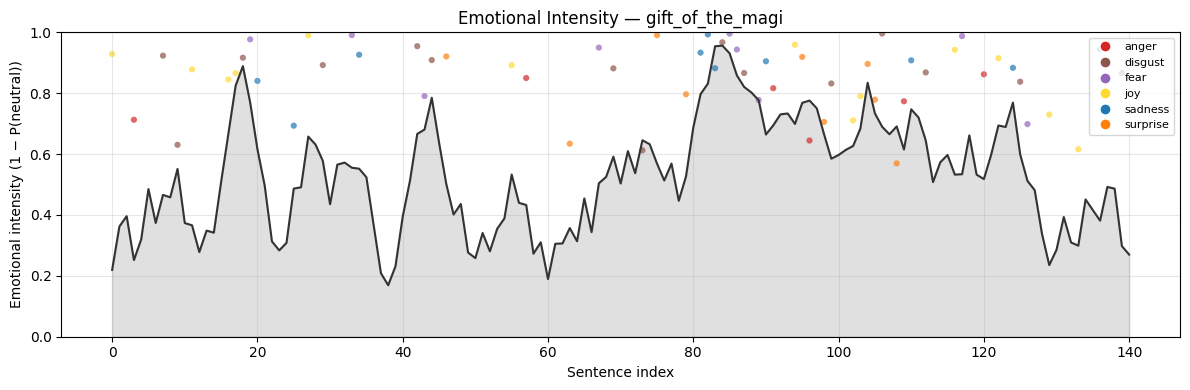

In [6]:
outputs_dir = project_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

emotion_visualizer.plot_intensity_arc(
    analyzed["sentence_emotions"],
    title=f"Emotional Intensity \u2014 {STORY_KEY}",
    save_path=outputs_dir / f"{STORY_KEY}_intensity.png",
)
import matplotlib.pyplot as plt
plt.show()

  Saved plot -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/outputs/gift_of_the_magi_arc.png


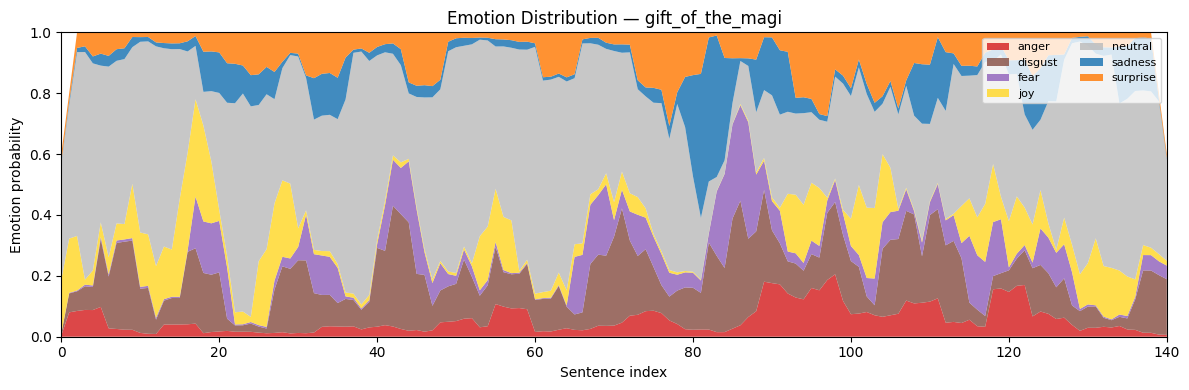

In [7]:
emotion_visualizer.plot_emotion_arc(
    analyzed["sentence_emotions"],
    title=f"Emotion Distribution \u2014 {STORY_KEY}",
    save_path=outputs_dir / f"{STORY_KEY}_arc.png",
)
plt.show()

## Step 6 — Build the emotion-aware summary

This is where Phase 3 happens. Strategy:
1. Pick **anchor sentences** — the top 20% by emotional intensity
2. For text between anchors, run abstractive summarization (DistilBART)
3. Stitch anchors (verbatim) and bridges (summarized) back together

**Why this approach:** standard summarizers strip emotional nuance because they optimize for information density. Anchoring on emotion peaks forces the summary to preserve the story's turning points.

In [8]:
summary_path = processed_dir / f"{STORY_KEY}_summary.json"

if summary_path.exists():
    print(f"Loading cached summary from {summary_path.name}")
    with summary_path.open(encoding="utf-8") as f:
        result = json.load(f)
else:
    # This downloads the ~300MB DistilBART model on first run.
    # The emotion model is unloaded first to keep RAM usage low.
    result = summarizer.summarize_analyzed_file(
        analyzed_path, output_path=summary_path
    )

summary = result["summary"]
print(f"\nAnchors chosen: {len(summary['anchor_indices'])} sentences")
print(f"Anchor indices: {summary['anchor_indices']}")
print(f"Compression: {summary['compression_ratio']:.0%} of original length")

[summarizer] Loading sshleifer/distilbart-cnn-12-6 on device=mps...
[summarizer] Model loaded.
  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/gift_of_the_magi_summary.json
  Compression: 24% of original length

Anchors chosen: 10 sentences
Anchor indices: [19, 27, 33, 75, 82, 84, 85, 94, 106, 117]
Compression: 24% of original length


In [9]:
# Render the summary, showing which parts are anchors (verbatim) vs bridges (compressed)
print("=" * 70)
print(f"EMOTION-AWARE SUMMARY \u2014 {STORY_KEY}")
print("=" * 70)
print()
for i, seg in enumerate(summary["segments"]):
    if seg["kind"] == "anchor":
        emo = seg["emotion"]["top_label"]
        print(f"  \u2605 [{emo.upper()}] {seg['text']}")
    else:
        print(f"    {seg['text']}")
    print()

EMOTION-AWARE SUMMARY — gift_of_the_magi

    The Gift of the Magi by O. Henry was published in 1922 . The story follows the story of a woman in a furnished flat at $8 per week . O.Henry: Life is made up of sobs, sniffles, and smiles .

  ★ [FEAR] She stood by the window and looked out dully at a gray cat walking a gray fence in a gray backyard.

    Tomorrow would be Christmas Day, and she had only $1.87 with which to buy Jim a present . She had been saving every penny she could for months . Expenses had been greater than she had calculated .

  ★ [JOY] Many a happy hour she had spent planning for something nice for him.

    Something just a little bit near to being worthy of being owned by Jim . Perhaps you have seen a pier glass in an $8 flat . A very thin and very agile person may, by observing his reflection in a rapid sequence of longitudinal strips, obtain a fairly accurate conception of his looks .

  ★ [FEAR] Suddenly she whirled from the window and stood before the glass.

 

## Step 7 — Process all the other stories

Same pipeline for the remaining stories. Caches kick in if you've already run any of them.

In [10]:
for key in downloaded:
    if key == STORY_KEY:
        continue  # already done above

    print(f"\n--- {key} ---")
    seg_path = processed_dir / f"{key}_segmented.json"
    ana_path = processed_dir / f"{key}_analyzed.json"
    sum_path = processed_dir / f"{key}_summary.json"

    # Emotion analysis
    if not ana_path.exists():
        emotion_analyzer.analyze_segmented_file(seg_path, output_path=ana_path)
    else:
        print(f"  emotion analysis cached.")

    # Summarization
    if not sum_path.exists():
        summarizer.summarize_analyzed_file(ana_path, output_path=sum_path)
    else:
        print(f"  summary cached.")

print("\n\u2705 All stories processed.")


--- the_necklace ---
Analyzing 3153 sentences from the_necklace_segmented.json...
[emotion] Loading j-hartmann/emotion-english-distilroberta-base on device=mps...
[emotion] Model loaded (82M params).


Emotion analysis: 100%|█████████████████████████████████████████████████████████████████████████████████████| 198/198 [00:34<00:00,  5.76batch/s]


  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/the_necklace_analyzed.json
[summarizer] Loading sshleifer/distilbart-cnn-12-6 on device=mps...
[summarizer] Model loaded.
  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/the_necklace_summary.json
  Compression: 1% of original length

--- tell_tale_heart ---
Analyzing 154 sentences from tell_tale_heart_segmented.json...
[emotion] Loading j-hartmann/emotion-english-distilroberta-base on device=mps...
[emotion] Model loaded (82M params).


Emotion analysis: 100%|███████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.58batch/s]


  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/tell_tale_heart_analyzed.json
[summarizer] Loading sshleifer/distilbart-cnn-12-6 on device=mps...
[summarizer] Model loaded.
  Saved -> /Users/kavindumihiranga/Documents/NextJS/emotional-audiobook/V3/emotional_audiobook/data/processed/tell_tale_heart_summary.json
  Compression: 30% of original length

✅ All stories processed.


## Step 8 — Quick comparison across stories

How did each story compress? And what was the dominant emotion?

In [11]:
print(f"{'Story':<22s} {'Sentences':>10s} {'Anchors':>9s} {'Compression':>12s}  Top emotion")
print("-" * 75)
for key in downloaded:
    sum_path = processed_dir / f"{key}_summary.json"
    if not sum_path.exists():
        continue
    with sum_path.open(encoding="utf-8") as f:
        d = json.load(f)
    dist = emotion_analyzer.emotion_distribution(d["sentence_emotions"])
    # Pick top non-neutral emotion if possible
    top_emo = max(
        (k for k in dist if k != "neutral"),
        key=lambda k: dist[k]
    )
    print(
        f"{key:<22s} {len(d['sentence_emotions']):>10d} "
        f"{len(d['summary']['anchor_indices']):>9d} "
        f"{d['summary']['compression_ratio']:>11.0%}  "
        f"{top_emo} ({dist[top_emo]:.0%})"
    )

Story                   Sentences   Anchors  Compression  Top emotion
---------------------------------------------------------------------------
gift_of_the_magi              141        10         24%  disgust (11%)
the_necklace                 3153        10          1%  disgust (21%)
tell_tale_heart               154        10         30%  fear (29%)


## Phase 2 + 3 — Complete ✅

**What we built:**
- Per-sentence emotion classification (7 emotions, confidence scores)
- Emotional-arc visualizations
- An emotion-aware summarizer that preserves emotional peaks verbatim while compressing the rest

**Data ready for Phase 4 (TTS):**
Each `*_summary.json` contains a `summary.segments` list. Each segment has:
- `text` — what to speak
- `kind` — `anchor` or `bridge`
- `emotion` — for anchors, the dominant emotion + full distribution

Phase 4 will use the `emotion` field to choose voice tone for each segment.